# 채널 가치 분석: 상위 2개 채널 선정

## 분석 목적
Q2. "어떤 채널에서 들어온 유저가 가장 가치 있는가?"

7개 마케팅 채널 중 **상위 2개 채널**을 선정하여 집중 투자 대상을 도출합니다.

## 가치 판단 지표 (4가지)
| # | 지표 | 설명 |
|---|------|------|
| 1 | **전환율 (CVR)** | 신규 유저 중 유료 결제 완료(completed) 비율 |
| 2 | **ARPU** | 활성 사용자 1인당 평균 매출 (3개월) |
| 3 | **LTV/CAC** | 고객 생애 가치 대비 획득 비용 효율 |
| 4 | **D7/D30 리텐션** | 가입 후 W1(1~7일) / W3~W4(15~30일) 범위 잔존율 |

- **분석 기간**: 2025년 3월 ~ 5월
- **데이터셋**: Users, Payment_transactions, Campaigns, Event_logs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('분석 환경 준비 완료')

분석 환경 준비 완료


## 1. 데이터 로드 및 코호트 설정

In [2]:
# 데이터 로드
users = pd.read_csv('./data/users.csv', parse_dates=['signup_date'])
payments = pd.read_csv('./data/payment_transactions.csv', parse_dates=['transaction_date'])
campaigns = pd.read_csv('./data/campaigns.csv', parse_dates=['start_date', 'end_date'])
events = pd.read_csv('./data/event_logs.csv', parse_dates=['event_timestamp'])

# 분석 기간: 2025년 3~5월
start_dt = pd.Timestamp('2025-03-01')
end_dt = pd.Timestamp('2025-05-31')

# 코호트 유저 (해당 기간 가입자)
cohort = users[(users['signup_date'] >= start_dt) & (users['signup_date'] <= end_dt)].copy()
cohort_ids = cohort['user_id'].unique()

print(f'분석 기간: {start_dt.date()} ~ {end_dt.date()}')
print(f'코호트 유저 수: {len(cohort_ids):,}명')
print(f'채널 수: {cohort["acquisition_source"].nunique()}개')
print(f'채널 목록: {sorted(cohort["acquisition_source"].unique())}')

분석 기간: 2025-03-01 ~ 2025-05-31
코호트 유저 수: 10,311명
채널 수: 7개
채널 목록: ['content_marketing', 'google_ads', 'instagram_influencer', 'meta_ads', 'organic', 'referral', 'youtube']


## 2. 지표 1: 전환율 (CVR)
신규 유저 중 유료 결제(status=completed)를 완료한 비율

In [3]:
# 코호트 유저의 결제 내역 (completed만)
paid = payments[(payments['user_id'].isin(cohort_ids)) & (payments['status'] == 'completed')]
paid_user_ids = paid['user_id'].unique()

# 유저별 결제 여부 및 총 결제액
revenue = paid.groupby('user_id')['amount'].sum().reset_index()
merged = pd.merge(cohort[['user_id', 'acquisition_source']], revenue, on='user_id', how='left').fillna(0)
merged['is_paid'] = merged['amount'] > 0

# 채널별 전환율 & ARPU
ch = merged.groupby('acquisition_source').agg(
    user_count=('user_id', 'count'),
    paid_count=('is_paid', 'sum'),
    cvr=('is_paid', 'mean'),
    arpu=('amount', 'mean')
).reset_index()

print('=== 채널별 전환율 (CVR) ===')
display(ch[['acquisition_source', 'user_count', 'paid_count', 'cvr']].sort_values('cvr', ascending=False))

=== 채널별 전환율 (CVR) ===


,acquisition_source,user_count,paid_count,cvr
5,referral,828,275,0.332126
1,google_ads,2071,642,0.309995
6,youtube,1837,529,0.287970
4,organic,2040,487,0.238725
0,content_marketing,1442,317,0.219834
2,instagram_influencer,787,157,0.199492
3,meta_ads,1306,231,0.176876


## 3. 지표 2: ARPU (Average Revenue Per User)
3개월 분석 기간 동안 활성 사용자 1인이 창출하는 평균 매출

In [4]:
print('=== 채널별 ARPU ===')
display(ch[['acquisition_source', 'user_count', 'arpu']].sort_values('arpu', ascending=False))

=== 채널별 ARPU ===


,acquisition_source,user_count,arpu
1,google_ads,2071,19351.472718
5,referral,828,19115.338164
6,youtube,1837,17104.844856
4,organic,2040,14363.284314
0,content_marketing,1442,12152.427184
2,instagram_influencer,787,11429.351970
3,meta_ads,1306,9324.885145


## 4. 지표 3: LTV / CAC
- **LTV** (고객 생애 가치) = ARPU를 proxy로 사용
- **CAC** (고객 획득 비용) = 기간 내 광고비 / 유입 유저 수
- **LTV/CAC > 1** 이면 투자 대비 수익이 발생하는 것

In [5]:
# 캠페인 비용 계산 (분석 기간 내 집행액)
camps = campaigns.copy()
camps['p_end'] = camps['end_date'].fillna(end_dt)

def get_spend(row):
    s = max(row['start_date'], start_dt)
    e = min(row['p_end'], end_dt)
    days = max(0, (e - s).days + 1)
    return days * row['daily_budget']

camps['spend'] = camps.apply(get_spend, axis=1)
spend_by_ch = camps.groupby('channel')['spend'].sum().reset_index()

# 채널 통계에 결합
ch = pd.merge(ch, spend_by_ch, left_on='acquisition_source', right_on='channel', how='left').fillna(0)
ch['cac'] = ch.apply(lambda r: r['spend'] / r['user_count'] if r['user_count'] > 0 else 0, axis=1)
ch['ltv_cac'] = ch.apply(lambda r: r['arpu'] / r['cac'] if r['cac'] > 0 else np.nan, axis=1)

print('=== 채널별 LTV/CAC 효율 ===')
display(ch[['acquisition_source', 'arpu', 'spend', 'cac', 'ltv_cac']].sort_values('ltv_cac', ascending=False))

=== 채널별 LTV/CAC 효율 ===


,acquisition_source,arpu,spend,cac,ltv_cac
6,youtube,17104.844856,10120000.0,5508.982036,3.104901
1,google_ads,19351.472718,14720000.0,7107.677451,2.722615
2,instagram_influencer,11429.351970,9200000.0,11689.961881,0.977707
3,meta_ads,9324.885145,12880000.0,9862.174579,0.945520
0,content_marketing,12152.427184,0.0,0.000000,NaN
4,organic,14363.284314,0.0,0.000000,NaN
5,referral,19115.338164,0.0,0.000000,NaN


## 5. 지표 4: D7 / D30 범위(Bracket) 리텐션
- **D7 (W1)**: `1 <= gap_days <= 7` (온보딩 및 초기 탐색 리텐션)
- **D30 (W3~W4)**: `15 <= gap_days <= 30` (학습 습관 정착 리텐션)


In [6]:
# 이벤트 로그 + 가입일 결합
ev = events[events['user_id'].isin(cohort_ids)].merge(
    cohort[['user_id', 'signup_date', 'acquisition_source']], on='user_id'
)
ev['gap_days'] = (ev['event_timestamp'].dt.normalize() - ev['signup_date'].dt.normalize()).dt.days

# D7 / D30 범위(Bracket) 잔존 유저
d7_ids = ev[(ev['gap_days'] >= 1) & (ev['gap_days'] <= 7)]['user_id'].unique()
d30_ids = ev[(ev['gap_days'] >= 15) & (ev['gap_days'] <= 30)]['user_id'].unique()

merged['d7'] = merged['user_id'].isin(d7_ids)
merged['d30'] = merged['user_id'].isin(d30_ids)

ret = merged.groupby('acquisition_source').agg(
    d7_rate=('d7', 'mean'),
    d30_rate=('d30', 'mean')
).reset_index()

ch = pd.merge(ch, ret, on='acquisition_source')

print('=== 채널별 리텐션 ===')
display(ch[['acquisition_source', 'd7_rate', 'd30_rate']].sort_values('d7_rate', ascending=False))

=== 채널별 리텐션 ===


,acquisition_source,d7_rate,d30_rate
1,google_ads,0.907291,0.267504
5,referral,0.893720,0.435990
6,youtube,0.880784,0.358193
0,content_marketing,0.864078,0.273925
2,instagram_influencer,0.857687,0.219822
3,meta_ads,0.856815,0.133231
4,organic,0.854412,0.333333


## 6. 종합 스코어링 및 상위 2개 채널 선정

### 가중치
| 지표 | 가중치 | 이유 |
|------|--------|------|
| LTV/CAC (ROI) | 40% | 투자 효율 = 핵심 의사결정 기준 |
| 전환율 (CVR) | 30% | 유료 전환 능력 |
| ARPU | 15% | 매출 기여도 |
| 리텐션 (D7+D30) | 15% | 장기 유지력 |

In [7]:
def norm(s):
    if s.max() == s.min():
        return pd.Series([100]*len(s), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

df = ch.copy()

# LTV/CAC에서 NaN(오가닉 등 CAC=0)은 별도 처리
df['ltv_cac_filled'] = df['ltv_cac'].fillna(df['ltv_cac'].max())

df['s_roi'] = norm(df['ltv_cac_filled'])
df['s_cvr'] = norm(df['cvr'])
df['s_arpu'] = norm(df['arpu'])
df['s_ret'] = norm(df['d7_rate'] + df['d30_rate'])

df['final_score'] = df['s_roi']*0.4 + df['s_cvr']*0.3 + df['s_arpu']*0.15 + df['s_ret']*0.15
df = df.sort_values('final_score', ascending=False).reset_index(drop=True)

print('=== 최종 종합 스코어 ===')
display(df[['acquisition_source', 'cvr', 'arpu', 'ltv_cac', 'd7_rate', 'd30_rate', 'final_score']])

=== 최종 종합 스코어 ===


,acquisition_source,cvr,arpu,ltv_cac,d7_rate,d30_rate,final_score
0,referral,0.332126,19115.338164,NaN,0.893720,0.435990,99.646737
1,youtube,0.287970,17104.844856,3.104901,0.880784,0.358193,84.099489
2,google_ads,0.309995,19351.472718,2.722615,0.907291,0.267504,81.800926
3,organic,0.238725,14363.284314,NaN,0.854412,0.333333,68.219830
4,content_marketing,0.219834,12152.427184,NaN,0.864078,0.273925,59.065033
5,instagram_influencer,0.199492,11429.351970,0.977707,0.857687,0.219822,11.977256
6,meta_ads,0.176876,9324.885145,0.945520,0.856815,0.133231,0.000000


## 7. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

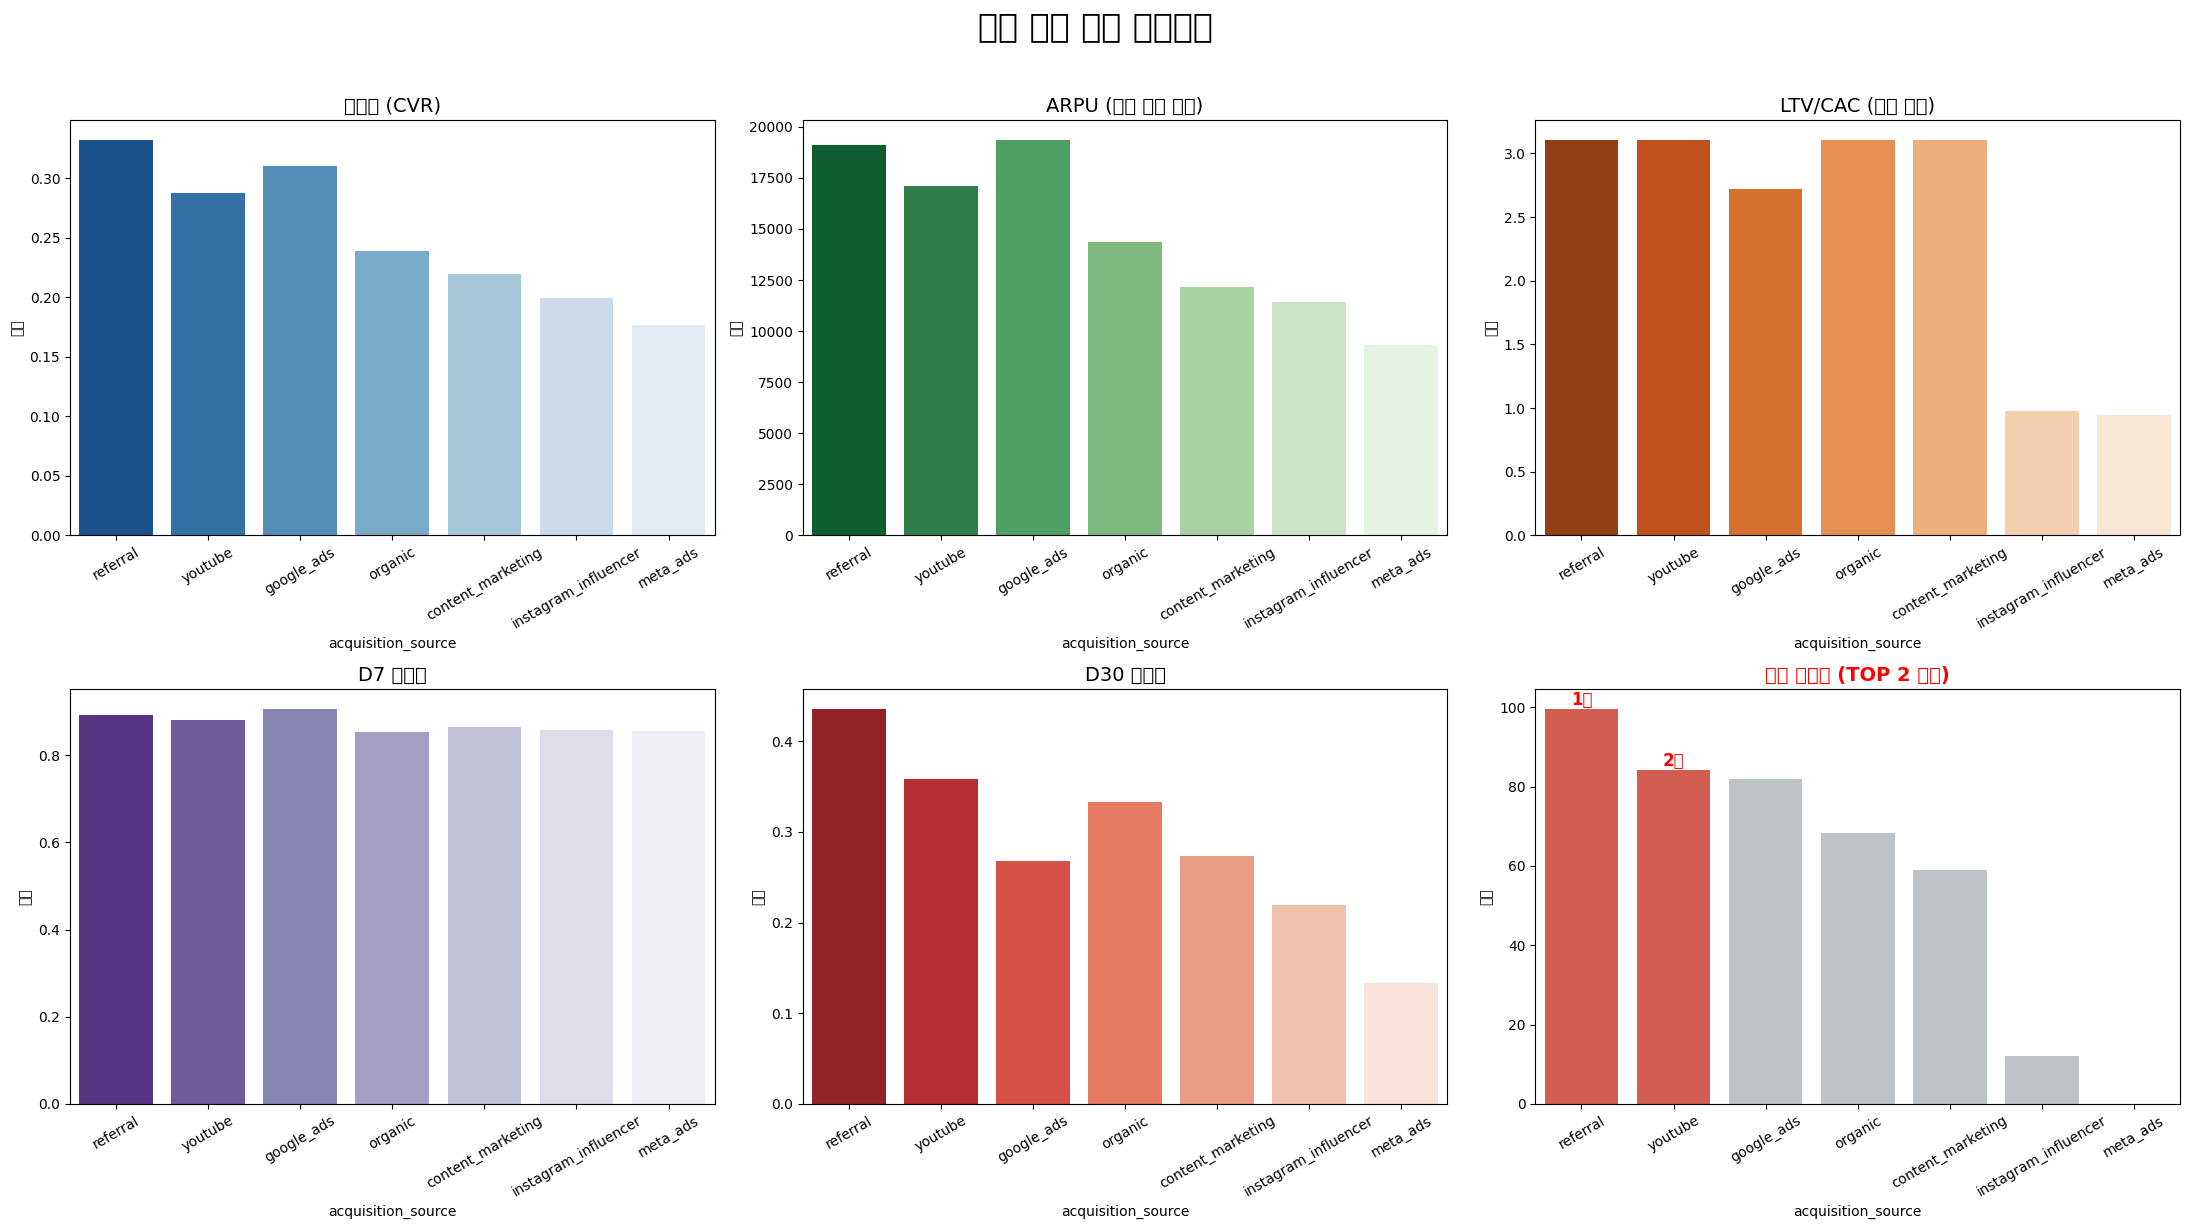

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('채널 가치 분석 대시보드', fontsize=24, fontweight='bold', y=1.02)

# 1) CVR
sns.barplot(data=df, x='acquisition_source', y='cvr', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('전환율 (CVR)', fontsize=14)
axes[0,0].set_ylabel('비율')
axes[0,0].tick_params(axis='x', rotation=30)

# 2) ARPU
sns.barplot(data=df, x='acquisition_source', y='arpu', ax=axes[0,1], palette='Greens_r')
axes[0,1].set_title('ARPU (인당 평균 매출)', fontsize=14)
axes[0,1].set_ylabel('금액')
axes[0,1].tick_params(axis='x', rotation=30)

# 3) LTV/CAC
sns.barplot(data=df, x='acquisition_source', y='ltv_cac_filled', ax=axes[0,2], palette='Oranges_r')
axes[0,2].set_title('LTV/CAC (투자 효율)', fontsize=14)
axes[0,2].set_ylabel('배수')
axes[0,2].tick_params(axis='x', rotation=30)

# 4) D7 Retention
sns.barplot(data=df, x='acquisition_source', y='d7_rate', ax=axes[1,0], palette='Purples_r')
axes[1,0].set_title('D7 리텐션', fontsize=14)
axes[1,0].set_ylabel('비율')
axes[1,0].tick_params(axis='x', rotation=30)

# 5) D30 Retention
sns.barplot(data=df, x='acquisition_source', y='d30_rate', ax=axes[1,1], palette='Reds_r')
axes[1,1].set_title('D30 리텐션', fontsize=14)
axes[1,1].set_ylabel('비율')
axes[1,1].tick_params(axis='x', rotation=30)

# 6) Final Score (상위 2개 강조)
bar_colors = ['#E74C3C' if i < 2 else '#BDC3C7' for i in range(len(df))]
sns.barplot(data=df, x='acquisition_source', y='final_score', ax=axes[1,2], palette=bar_colors)
axes[1,2].set_title('종합 스코어 (TOP 2 강조)', fontsize=14, color='red', fontweight='bold')
axes[1,2].set_ylabel('점수')
axes[1,2].tick_params(axis='x', rotation=30)

for i, p in enumerate(axes[1,2].patches):
    label = f'{i+1}위' if i < 2 else ''
    axes[1,2].annotate(label, (p.get_x()+p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## 8. 결론: 상위 2개 채널 선정 결과

In [9]:
top2 = df.head(2)
print('=' * 60)
print('  상위 2개 채널 선정 결과')
print('=' * 60)
for idx, row in top2.iterrows():
    print(f"\n  {idx+1}위: {row['acquisition_source']}")
    print(f"     - 종합 스코어: {row['final_score']:.1f}")
    print(f"     - 전환율: {row['cvr']:.2%}")
    print(f"     - ARPU: {row['arpu']:,.0f}원")
    print(f"     - LTV/CAC: {row['ltv_cac']:.2f}배" if pd.notna(row['ltv_cac']) else f"     - LTV/CAC: N/A (오가닉)")
    print(f"     - D7 리텐션: {row['d7_rate']:.2%}")
    print(f"     - D30 리텐션: {row['d30_rate']:.2%}")
print('\n' + '=' * 60)
print('  한문장 정리: 채널별 비교를 통해 예산을 재분배하여')
print(f'  [{top2.iloc[0]["acquisition_source"]}]과 [{top2.iloc[1]["acquisition_source"]}]에 집중 투자한다.')
print('=' * 60)

  상위 2개 채널 선정 결과

  1위: referral
     - 종합 스코어: 99.6
     - 전환율: 33.21%
     - ARPU: 19,115원
     - LTV/CAC: N/A (오가닉)
     - D7 리텐션: 89.37%
     - D30 리텐션: 43.60%

  2위: youtube
     - 종합 스코어: 84.1
     - 전환율: 28.80%
     - ARPU: 17,105원
     - LTV/CAC: 3.10배
     - D7 리텐션: 88.08%
     - D30 리텐션: 35.82%

  한문장 정리: 채널별 비교를 통해 예산을 재분배하여
  [referral]과 [youtube]에 집중 투자한다.
